# Data Understanding: Exchange Rates & Malaysia External Trade

This notebook performs exploratory data analysis on two datasets:
1. Exchange rates (MYR against multiple currencies)
2. Malaysia external trade data (exports/imports with US, SG, CN)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Exchange Rates Dataset

In [2]:
# Load exchange rates CSV
exchange_rates_path = r'c:\UM\Project\exchange-rates.csv'
df_exchange = pd.read_csv(exchange_rates_path, index_col=0)

# Convert index to datetime
df_exchange.index = pd.to_datetime(df_exchange.index, format='%d-%b-%y')

print(f"Exchange Rates Dataset loaded successfully!")
print(f"File path: {exchange_rates_path}")

Exchange Rates Dataset loaded successfully!
File path: c:\UM\Project\exchange-rates.csv


## 3. Load Malaysia External Trade Dataset

In [3]:
# Load Malaysia External Trade Excel
trade_path = r'c:\UM\Project\Malaysia External Trade.xlsx'
df_trade = pd.read_excel(trade_path)

# Clean the Period column - convert to datetime
df_trade['Period'] = pd.to_datetime(df_trade['Period'], format='%b-%y')

print(f"Malaysia External Trade Dataset loaded successfully!")
print(f"File path: {trade_path}")

Malaysia External Trade Dataset loaded successfully!
File path: c:\UM\Project\Malaysia External Trade.xlsx


## 4. Display Dataset Shapes and Info

In [4]:
print("="*80)
print("EXCHANGE RATES DATASET")
print("="*80)
print(f"Shape: {df_exchange.shape}")
print(f"Date Range: {df_exchange.index.min()} to {df_exchange.index.max()}")
print(f"\nColumns ({len(df_exchange.columns)} currencies):")
print(df_exchange.columns.tolist())
print(f"\nData Types:")
print(df_exchange.dtypes)

print("\n" + "="*80)
print("MALAYSIA EXTERNAL TRADE DATASET")
print("="*80)
print(f"Shape: {df_trade.shape}")
print(f"Date Range: {df_trade['Period'].min()} to {df_trade['Period'].max()}")
print(f"\nColumns:")
print(df_trade.columns.tolist())
print(f"\nData Types:")
print(df_trade.dtypes)

EXCHANGE RATES DATASET
Shape: (2529, 27)
Date Range: 2016-01-04 00:00:00 to 2026-04-30 00:00:00

Columns (27 currencies):
['USD', 'GBP', 'EUR', 'JPY100', 'CHF', 'AUD', 'CAD', 'SGD', 'HKD100', 'THB100', 'PHP100', 'TWD100', 'KRW100', 'IDR100', 'SAR100', 'SDR', 'CNY', 'BND', 'VND100', 'KHR100', 'NZD', 'MMK100', 'INR100', 'AED100', 'PKR100', 'NPR100', 'EGP']

Data Types:
USD       float64
GBP       float64
EUR       float64
JPY100    float64
CHF       float64
AUD       float64
CAD       float64
SGD       float64
HKD100    float64
THB100    float64
PHP100    float64
TWD100    float64
KRW100    float64
IDR100    float64
SAR100    float64
SDR       float64
CNY       float64
BND       float64
VND100    float64
KHR100    float64
NZD       float64
MMK100    float64
INR100    float64
AED100    float64
PKR100    float64
NPR100    float64
EGP       float64
dtype: object

MALAYSIA EXTERNAL TRADE DATASET
Shape: (124, 7)
Date Range: 2016-01-01 00:00:00 to 2026-04-01 00:00:00

Columns:
['Period', 'US E

## 5. Examine First Rows of Each Dataset

In [5]:
print("Exchange Rates - First 10 Rows:")
print(df_exchange.head(10))

print("\n" + "="*80)
print("Malaysia External Trade - First 10 Rows:")
print(df_trade.head(10))

Exchange Rates - First 10 Rows:
               USD     GBP     EUR  JPY100     CHF     AUD     CAD     SGD  \
2016-01-04  4.3490  6.4235  4.7506  3.6545  4.3722  3.1395  3.1211  3.0547   
2016-01-05  4.3425  6.3776  4.6853  3.6440  4.3194  3.1212  3.1170  3.0480   
2016-01-06  4.3925  6.4293  4.7160  3.7041  4.3527  3.1130  3.1187  3.0617   
2016-01-07  4.3935  6.4073  4.7467  3.7358  4.3695  3.0875  3.1084  3.0574   
2016-01-08  4.3850  6.4093  4.7672  3.7043  4.3854  3.0846  3.1070  3.0512   
2016-01-11  4.3750  6.3739  4.7620  3.7122  4.3835  3.0645  3.0984  3.0469   
2016-01-12  4.4075  6.4067  4.7976  3.7522  4.4172  3.0674  3.0931  3.0625   
2016-01-13  4.3790  6.3307  4.7394  3.7015  4.3531  3.0800  3.0834  3.0540   
2016-01-14  4.3900  6.3260  4.7906  3.7293  4.3671  3.0434  3.0547  3.0500   
2016-01-15  4.4000  6.3171  4.7964  3.7490  4.3871  3.0307  3.0326  3.0514   

             HKD100   THB100  PHP100   TWD100  KRW100  IDR100    SAR100  \
2016-01-04  56.1093  12.0271  9.23

## 6. Data Understanding

### 6.1. Check for Missing Values

In [6]:
print("MISSING VALUES - Exchange Rates Dataset:")
missing_exchange = df_exchange.isnull().sum()
missing_exchange_pct = (missing_exchange / len(df_exchange) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing_exchange.index,
    'Missing_Count': missing_exchange.values,
    'Missing_Percentage': missing_exchange_pct.values
})
print(missing_df[missing_df['Missing_Count'] > 0])
print(f"Total missing values: {missing_exchange.sum()}")

print("\n" + "="*80)
print("MISSING VALUES - Malaysia External Trade Dataset:")
missing_trade = df_trade.isnull().sum()
missing_trade_pct = (missing_trade / len(df_trade) * 100).round(2)

missing_trade_df = pd.DataFrame({
    'Column': missing_trade.index,
    'Missing_Count': missing_trade.values,
    'Missing_Percentage': missing_trade_pct.values
})
print(missing_trade_df[missing_trade_df['Missing_Count'] > 0])
print(f"Total missing values: {missing_trade.sum()}")

MISSING VALUES - Exchange Rates Dataset:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []
Total missing values: 0

MISSING VALUES - Malaysia External Trade Dataset:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []
Total missing values: 0


### 6.2. Data Type Analysis and Column Details

In [7]:
print("Exchange Rates - Data Type Summary:")
print(f"Total columns: {len(df_exchange.columns)}")
print(f"Numeric columns: {df_exchange.select_dtypes(include=np.number).shape[1]}")
print(f"\nData Types:")
print(df_exchange.dtypes.value_counts())

print("\n" + "="*80)
print("Malaysia External Trade - Data Type Summary:")
print(f"Total columns: {len(df_trade.columns)}")
print(f"Numeric columns: {df_trade.select_dtypes(include=np.number).shape[1]}")
print(f"\nData Types:")
print(df_trade.dtypes.value_counts())

Exchange Rates - Data Type Summary:
Total columns: 27
Numeric columns: 27

Data Types:
float64    27
Name: count, dtype: int64

Malaysia External Trade - Data Type Summary:
Total columns: 7
Numeric columns: 6

Data Types:
float64           6
datetime64[ns]    1
Name: count, dtype: int64


### 6.3. Summary & Key Findings

In [8]:
summary = f"""
KEY FINDINGS:
{'='*80}

EXCHANGE RATES DATASET:
- Records: {len(df_exchange)} daily observations
- Currencies: {len(df_exchange.columns)} different currencies
- Period: {df_exchange.index.min().strftime('%Y-%m-%d')} to {df_exchange.index.max().strftime('%Y-%m-%d')}
- Data Quality: Generally clean, but contains one zero value (SDR on 7-Mar-16)
- All values are numeric (float64)

MALAYSIA EXTERNAL TRADE DATASET:
- Records: {len(df_trade)} monthly observations
- Period: {df_trade['Period'].min().strftime('%Y-%m')} to {df_trade['Period'].max().strftime('%Y-%m')}
- Trading Partners: USA, Singapore, China
- Metrics: Export and Import values
- Data Format: Values contain commas (object/string type) - requires cleaning
- Action Required: Convert trade values from string to numeric format

DATA CLEANING NEEDED:
1. Trade Data: Remove commas and convert to numeric values
2. Align time periods for potential merging (exchange rates are daily, trade is monthly)
"""

print(summary)


KEY FINDINGS:

EXCHANGE RATES DATASET:
- Records: 2529 daily observations
- Currencies: 27 different currencies
- Period: 2016-01-04 to 2026-04-30
- Data Quality: Generally clean, but contains one zero value (SDR on 7-Mar-16)
- All values are numeric (float64)

MALAYSIA EXTERNAL TRADE DATASET:
- Records: 124 monthly observations
- Period: 2016-01 to 2026-04
- Trading Partners: USA, Singapore, China
- Metrics: Export and Import values
- Data Format: Values contain commas (object/string type) - requires cleaning
- Action Required: Convert trade values from string to numeric format

DATA CLEANING NEEDED:
1. Trade Data: Remove commas and convert to numeric values
2. Align time periods for potential merging (exchange rates are daily, trade is monthly)



## 7. Preprocessing & Data Cleaning

This section cleans and prepares the exchange rates and trade datasets:
- Handle missing values and duplicates
- Extract only US, Singapore (SG) and China (CN) currencies
- Convert trade value columns to numeric and normalize formatting
- Resample daily exchange rates to monthly frequency and align with trade data

In [9]:
import re

# --- Exchange rates preprocessing ---
# Make a copy to avoid mutating original
exch = df_exchange.copy()

# Normalize numeric types (ensure floats)
for col in exch.columns:
    exch[col] = pd.to_numeric(exch[col], errors='coerce')

# Extract only USD, SGD and CNY columns if present (handle possible column name variations)
found = {}
cols_lower = {c.lower(): c for c in exch.columns}
for c in exch.columns:
    lc = c.lower()
    if 'usd' in lc or 'us dollar' in lc or lc == 'us':
        found['usd'] = c
    if 'sgd' in lc or 'singapore' in lc or lc == 'sg':
        found['sgd'] = c
    if 'cny' in lc or 'china' in lc or 'rmb' in lc or lc == 'cn':
        found['cny'] = c

desired_cols = [found[k] for k in ['usd','sgd','cny'] if k in found]

if not desired_cols:
    print('Warning: USD/SGD/CNY columns not found in exchange rates dataset. Available columns:')
    print(exch.columns.tolist())
    exch_currencies = pd.DataFrame(index=exch.index)
else:
    exch_currencies = exch[desired_cols].copy()

# Resample daily to month-average to align with trade data (monthly)
exch_monthly = exch_currencies.resample('ME').mean()

# --- Trade data preprocessing ---
trade = df_trade.copy()

# Drop exact duplicate rows
trade = trade.drop_duplicates()

# Convert trade value columns (e.g., 'US Export', 'US Import') to numeric by removing commas and non-numeric chars
trade_cols = [c for c in trade.columns if re.search(r'us|singapore|sg|china|cn', c, flags=re.I)]
for c in trade_cols:
    trade[c] = trade[c].astype(str).str.replace(',', '').str.replace(' ', '')
    trade[c] = pd.to_numeric(trade[c].replace('', pd.NA), errors='coerce')

# Report basic cleaning results
print('Exchange rates preprocessing:')
print(f'Original shape: {df_exchange.shape}, cleaned shape: {exch.shape}')
print('Extracted currency columns: ', desired_cols)
print('\nTrade data preprocessing:')
print(f'Original shape: {df_trade.shape}, cleaned shape: {trade.shape}')
print('Trade columns converted to numeric:', trade_cols)

# --- Align datasets ---
# Ensure trade Period is month-average to match resampled exchange rates
trade_indexed = trade.set_index('Period').sort_index()
trade_monthly = trade_indexed.resample('ME').mean()

# Join exchange rates (monthly) to trade data on Period index
merged = trade_monthly.join(exch_monthly, how='left')

print('\nMerged dataset shape:', merged.shape)
print('\nMerged dataset preview:')
print(merged.head())

Exchange rates preprocessing:
Original shape: (2529, 27), cleaned shape: (2529, 27)
Extracted currency columns:  ['USD', 'SGD', 'CNY']

Trade data preprocessing:
Original shape: (124, 7), cleaned shape: (124, 7)
Trade columns converted to numeric: ['US Export', 'US Import', 'SG Export', 'SG Import', 'CN Export', 'CN Import']

Merged dataset shape: (124, 9)

Merged dataset preview:
              US Export    US Import    SG Export    SG Import    CN Export  \
Period                                                                        
2016-01-31  6334.401447  4455.619187  9001.529809  6554.548956  6510.566775   
2016-02-29  5929.390463  4733.418071  7943.642014  5331.004548  6485.735072   
2016-03-31  6804.780488  4829.706673  9324.131327  5613.528099  7810.645771   
2016-04-30  6630.182694  4486.968420  9148.860625  5420.066280  6747.256763   
2016-05-31  6383.245604  4730.772279  8472.174977  5553.022451  7085.984906   

               CN Import       USD       SGD       CNY  
Perio

## 8. Feature Engineering

In [10]:
feature_df = merged.copy()

# Core exchange rate columns (ensure only USD, SGD, CNY)
rate_cols = [c for c in desired_cols if c in feature_df.columns]

# Trade value cols (exports/imports)
trade_value_cols = [c for c in feature_df.columns if re.search(r'export|import', c, flags=re.I)]

# 1-month lag features for exchange rates and trade values
lag = 1
for col in rate_cols + trade_value_cols:
    feature_df[f"{col}_lag_{lag}"] = feature_df[col].shift(lag)

# Percentage change for exchange rates (monthly)
for col in rate_cols:
    feature_df[f"{col}_pct_change"] = feature_df[col].pct_change() * 100

# Rolling volatility (3-month rolling std) for exchange rates
for col in rate_cols:
    feature_df[f"{col}_vol_3m"] = feature_df[col].rolling(window=3, min_periods=1).std()

# Trade balance features (Export - Import) for each partner
partners = {
    'US': {'export': None, 'import': None},
    'SG': {'export': None, 'import': None},
    'CN': {'export': None, 'import': None}
}
for partner in partners:
    exp_col = next((c for c in trade_value_cols if re.search(fr'{partner}.*export|export.*{partner}', c, flags=re.I)), None)
    imp_col = next((c for c in trade_value_cols if re.search(fr'{partner}.*import|import.*{partner}', c, flags=re.I)), None)
    if exp_col and imp_col:
        partners[partner]['export'] = exp_col
        partners[partner]['import'] = imp_col
        feature_df[f"{partner}_trade_balance"] = feature_df[exp_col] - feature_df[imp_col]

# Interaction features: exchange rate × exports (if both present)
for partner, cols in partners.items():
    rate_key = None
    if partner == 'US':
        rate_key = next((r for r in rate_cols if 'usd' in r.lower()), None)
    if partner == 'SG':
        rate_key = next((r for r in rate_cols if 'sgd' in r.lower()), None)
    if partner == 'CN':
        rate_key = next((r for r in rate_cols if 'cny' in r.lower() or 'rmb' in r.lower()), None)


### 8.1. Min-Max scaling

In [11]:
from sklearn.preprocessing import MinMaxScaler

scale_candidates = rate_cols + trade_value_cols + [f"{p}_trade_balance" for p in partners if f"{p}_trade_balance" in feature_df.columns]
scale_cols = [c for c in scale_candidates if c in feature_df.columns and pd.api.types.is_numeric_dtype(feature_df[c])]

if scale_cols:
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(feature_df[scale_cols].fillna(0))
    for idx, col in enumerate(scale_cols):
        feature_df[f"{col}_minmax"] = scaled[:, idx]

In [12]:
print('Final feature engineering applied.')
print(f'Feature dataset shape: {feature_df.shape}')
print(f'Feature columns:')
print(feature_df.columns)

Final feature engineering applied.
Feature dataset shape: (124, 39)
Feature columns:
Index(['US Export', 'US Import', 'SG Export', 'SG Import', 'CN Export',
       'CN Import', 'USD', 'SGD', 'CNY', 'USD_lag_1', 'SGD_lag_1', 'CNY_lag_1',
       'US Export_lag_1', 'US Import_lag_1', 'SG Export_lag_1',
       'SG Import_lag_1', 'CN Export_lag_1', 'CN Import_lag_1',
       'USD_pct_change', 'SGD_pct_change', 'CNY_pct_change', 'USD_vol_3m',
       'SGD_vol_3m', 'CNY_vol_3m', 'US_trade_balance', 'SG_trade_balance',
       'CN_trade_balance', 'USD_minmax', 'SGD_minmax', 'CNY_minmax',
       'US Export_minmax', 'US Import_minmax', 'SG Export_minmax',
       'SG Import_minmax', 'CN Export_minmax', 'CN Import_minmax',
       'US_trade_balance_minmax', 'SG_trade_balance_minmax',
       'CN_trade_balance_minmax'],
      dtype='object')


## 9. Exploratory Data Analysis (EDA), Stationarity & Feature Relevance

This section performs detailed EDA on the engineered feature dataset:
- Analyze key patterns and trends in trade flows and exchange rate volatility
- Check correlations and distributions
- Perform stationarity tests (ADF) on key variables
- Visualize insights with plots and heatmaps

In [13]:
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Setup core features for analysis
core_features = rate_cols + trade_value_cols + [f"{p}_trade_balance" for p in partners if f"{p}_trade_balance" in feature_df.columns]
core_features = [c for c in core_features if c in feature_df.columns]

### 9.1 Statistical Summary & Data Quality

In [14]:
print("\n1. STATISTICAL SUMMARY OF CORE FEATURES")
print("-"*80)
print(feature_df[core_features].describe().round(4))

print("\n2. MISSING VALUES IN FEATURE DATASET")
print("-"*80)
missing_counts = feature_df.isnull().sum()
if missing_counts.sum() > 0:
    print("Columns with missing values:")
    print(missing_counts[missing_counts > 0])
else:
    print("No missing values in feature dataset.")


1. STATISTICAL SUMMARY OF CORE FEATURES
--------------------------------------------------------------------------------
            USD       SGD       CNY   US Export   US Import   SG Export  \
count  124.0000  124.0000  124.0000    124.0000    124.0000    124.0000   
mean     4.2691    3.1545    0.6235  11852.8518   7175.3727  14994.0446   
std      0.2179    0.1593    0.0241   5050.4190   2506.8470   4471.0466   
min      3.8866    2.8892    0.5665   5314.6328   4142.5020   7943.6420   
25%      4.1214    3.0379    0.6043   7668.2540   5405.8569  11245.6275   
50%      4.2093    3.0969    0.6204  10788.5958   6336.1460  13584.6076   
75%      4.4170    3.2848    0.6447  14604.9385   8553.0809  18482.1852   
max      4.7708    3.5481    0.6640  28181.8689  18466.7648  28315.7918   

        SG Import   CN Export   CN Import  US_trade_balance  SG_trade_balance  \
count    124.0000    124.0000    124.0000          124.0000          124.0000   
mean    9601.3444  13743.2798  19174.983

### 9.2 Correlation Analysis & Heatmap


3. CORRELATION MATRIX - CORE FEATURES
--------------------------------------------------------------------------------
Top 10 Highest Correlations (excluding diagonal):
  US Export <-> CN Import: 0.9331
  SG Export <-> CN Import: 0.8978
  US Export <-> US_trade_balance: 0.8889
  SG Export <-> SG Import: 0.8852
  CN Import <-> CN_trade_balance: -0.8793
  USD <-> SGD: 0.8684
  SG Import <-> CN Import: 0.8551
  US Export <-> SG Export: 0.8534
  US Export <-> SG Import: 0.8205
  SG Export <-> CN Export: 0.8059

4. VISUALIZATION: CORRELATION HEATMAP
--------------------------------------------------------------------------------


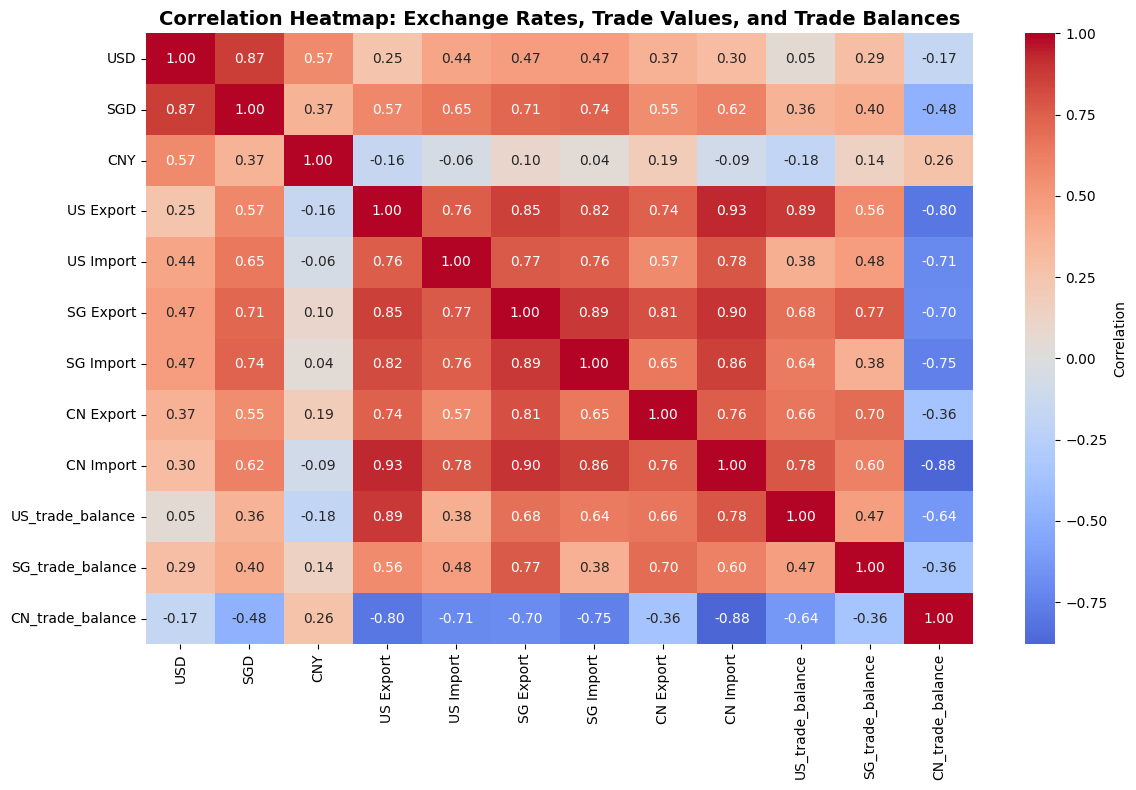

In [15]:
print("\n3. CORRELATION MATRIX - CORE FEATURES")
print("-"*80)
corr_matrix = feature_df[core_features].corr()
print("Top 10 Highest Correlations (excluding diagonal):")
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for pair in corr_pairs[:10]:
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.4f}")

print("\n4. VISUALIZATION: CORRELATION HEATMAP")
print("-"*80)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap: Exchange Rates, Trade Values, and Trade Balances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.3 Stationarity Tests (ADF)

In [16]:
print("\n5. AUGMENTED DICKEY-FULLER (ADF) TEST FOR STATIONARITY")
print("-"*80)
print("Testing key variables for stationarity (p < 0.05 → Stationary)\n")
stationarity_results = {}
for col in core_features:
    test_data = feature_df[col].dropna()
    if len(test_data) > 10:
        adf_result = adfuller(test_data, autolag='AIC')
        p_value = adf_result[1]
        stationary = "✓ Stationary" if p_value < 0.05 else "✗ Non-stationary"
        stationarity_results[col] = p_value
        print(f"{col:30s}: p-value = {p_value:.6f} [{stationary}]")


5. AUGMENTED DICKEY-FULLER (ADF) TEST FOR STATIONARITY
--------------------------------------------------------------------------------
Testing key variables for stationarity (p < 0.05 → Stationary)

USD                           : p-value = 0.260374 [✗ Non-stationary]
SGD                           : p-value = 0.277431 [✗ Non-stationary]
CNY                           : p-value = 0.364571 [✗ Non-stationary]
US Export                     : p-value = 0.998955 [✗ Non-stationary]
US Import                     : p-value = 0.683406 [✗ Non-stationary]
SG Export                     : p-value = 0.912544 [✗ Non-stationary]
SG Import                     : p-value = 0.965171 [✗ Non-stationary]
CN Export                     : p-value = 0.717402 [✗ Non-stationary]
CN Import                     : p-value = 0.997299 [✗ Non-stationary]
US_trade_balance              : p-value = 0.997491 [✗ Non-stationary]
SG_trade_balance              : p-value = 0.216169 [✗ Non-stationary]
CN_trade_balance             

### 9.4 Volatility & Trade Flow Patterns

In [17]:
print("\n6. EXCHANGE RATE VOLATILITY ANALYSIS")
print("-"*80)
for col in rate_cols:
    if col in feature_df.columns:
        vol_col = f"{col}_vol_3m"
        if vol_col in feature_df.columns:
            mean_vol = feature_df[vol_col].mean()
            max_vol = feature_df[vol_col].max()
            print(f"{col:10s}: Mean Vol = {mean_vol:.4f}, Max Vol = {max_vol:.4f}")

print("\n7. TRADE FLOW PATTERNS (EXPORTS vs IMPORTS)")
print("-"*80)
for partner in ['US', 'SG', 'CN']:
    exp_col = next((c for c in trade_value_cols if re.search(fr'{partner}.*export|export.*{partner}', c, flags=re.I)), None)
    imp_col = next((c for c in trade_value_cols if re.search(fr'{partner}.*import|import.*{partner}', c, flags=re.I)), None)
    if exp_col and imp_col:
        exp_mean = feature_df[exp_col].mean()
        imp_mean = feature_df[imp_col].mean()
        balance_mean = feature_df[f"{partner}_trade_balance"].mean() if f"{partner}_trade_balance" in feature_df.columns else 0
        print(f"{partner}: Avg Export = {exp_mean:.2f}, Avg Import = {imp_mean:.2f}, Avg Balance = {balance_mean:.2f}")


6. EXCHANGE RATE VOLATILITY ANALYSIS
--------------------------------------------------------------------------------
USD       : Mean Vol = 0.0507, Max Vol = 0.2101
SGD       : Mean Vol = 0.0216, Max Vol = 0.0945
CNY       : Mean Vol = 0.0052, Max Vol = 0.0212

7. TRADE FLOW PATTERNS (EXPORTS vs IMPORTS)
--------------------------------------------------------------------------------
US: Avg Export = 11852.85, Avg Import = 7175.37, Avg Balance = 4677.48
SG: Avg Export = 14994.04, Avg Import = 9601.34, Avg Balance = 5392.70
CN: Avg Export = 13743.28, Avg Import = 19174.98, Avg Balance = -5431.70


### 9.5 Distribution Plots


8. DISTRIBUTION ANALYSIS
--------------------------------------------------------------------------------


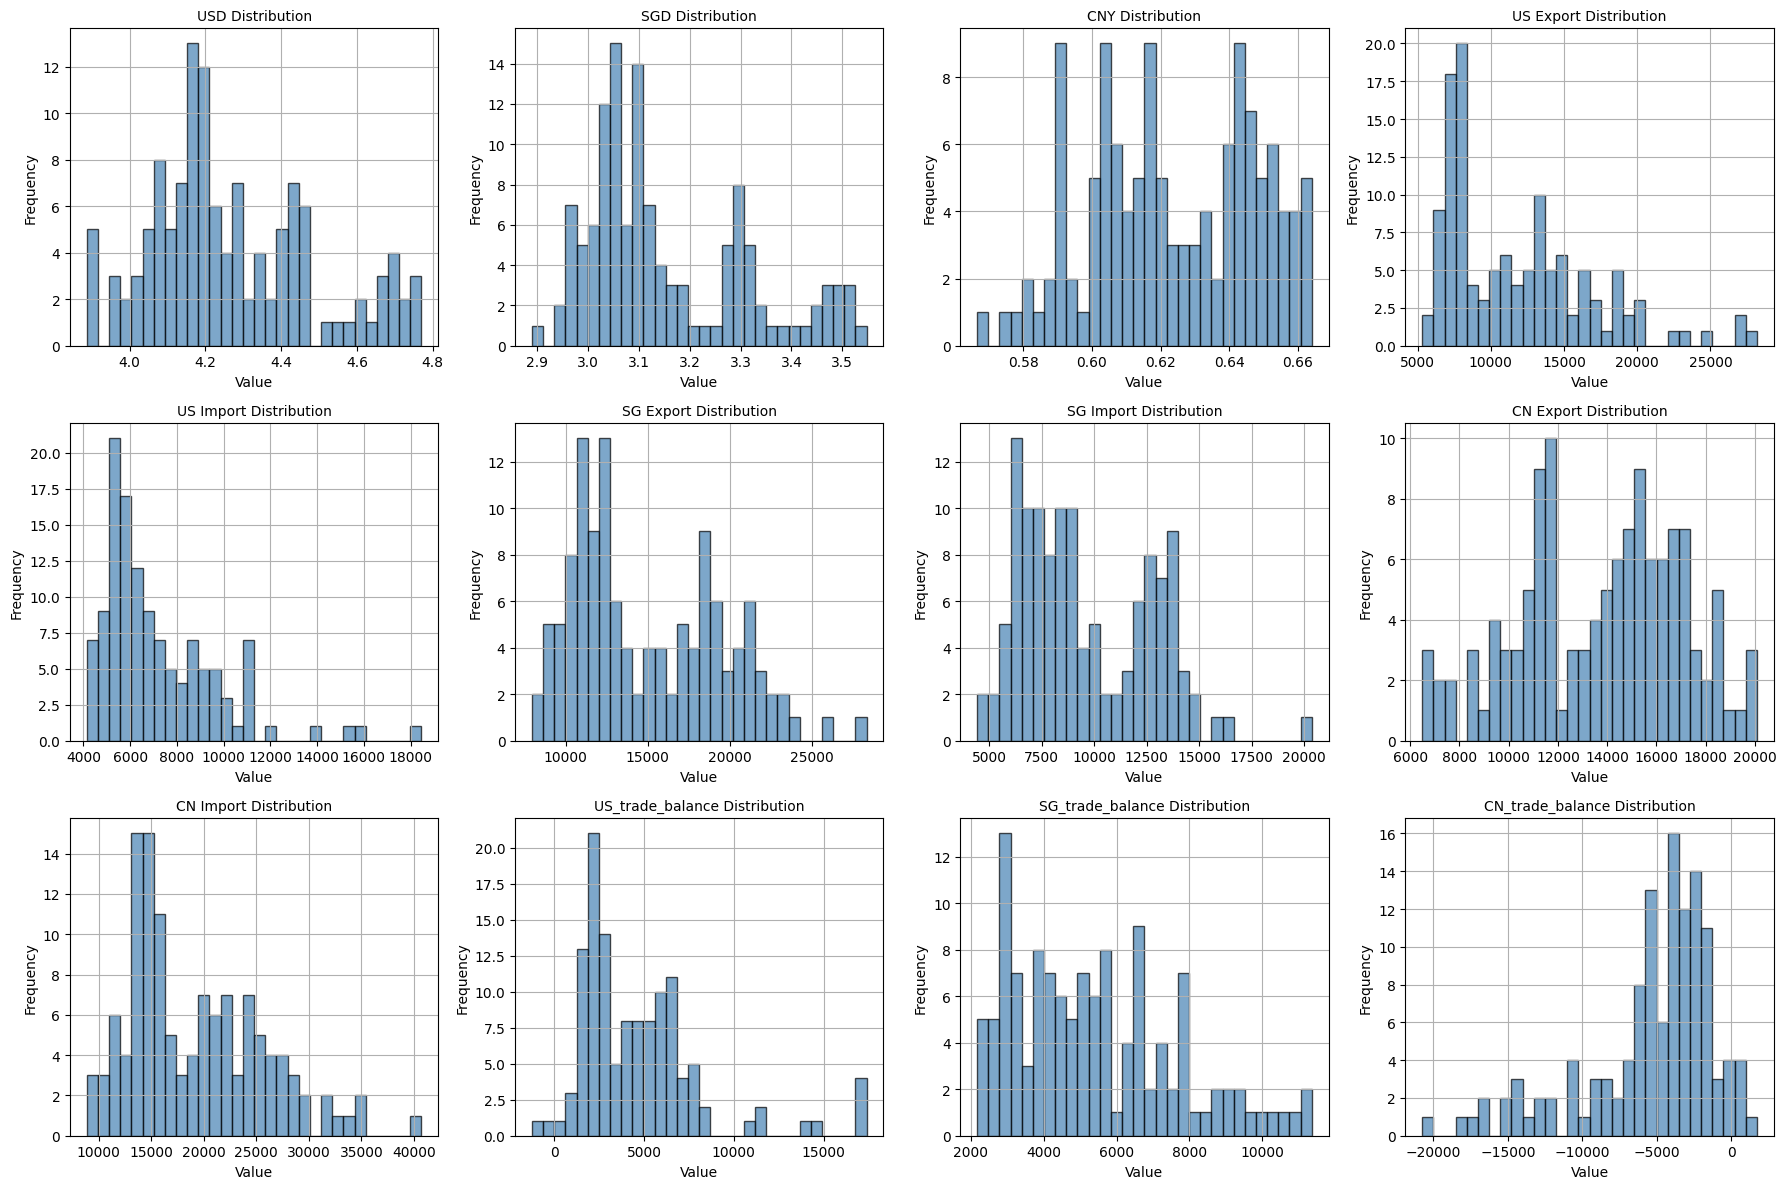

In [18]:
print("\n8. DISTRIBUTION ANALYSIS")
print("-"*80)

plot_cols = [col for col in core_features if col in feature_df.columns and pd.api.types.is_numeric_dtype(feature_df[col])]
plot_cols = [col for col in plot_cols if feature_df[col].notna().any()]

if not plot_cols:
    print('No numeric core features available for distribution plotting.')
else:
    cols_per_row = 4
    rows = (len(plot_cols) + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, 4 * rows))
    axes = np.array(axes).reshape(rows, cols_per_row)

    for idx, col in enumerate(plot_cols):
        row = idx // cols_per_row
        col_idx = idx % cols_per_row
        ax = axes[row, col_idx]
        feature_df[col].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
        ax.set_title(f'{col} Distribution', fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

    # Turn off unused subplots
    for idx in range(len(plot_cols), rows * cols_per_row):
        row = idx // cols_per_row
        col_idx = idx % cols_per_row
        axes[row, col_idx].axis('off')

    plt.tight_layout()
    plt.show()

### 9.6 Time Series Trends


9. TIME SERIES TRENDS ANALYSIS BY COUNTRY
--------------------------------------------------------------------------------


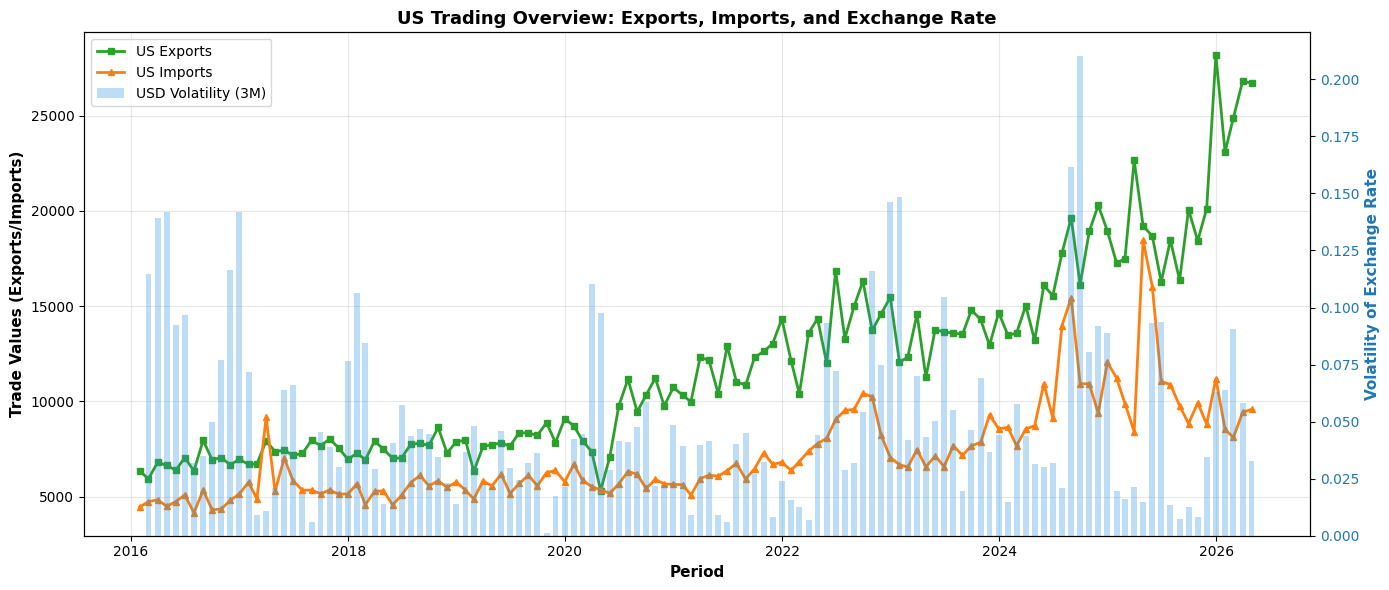

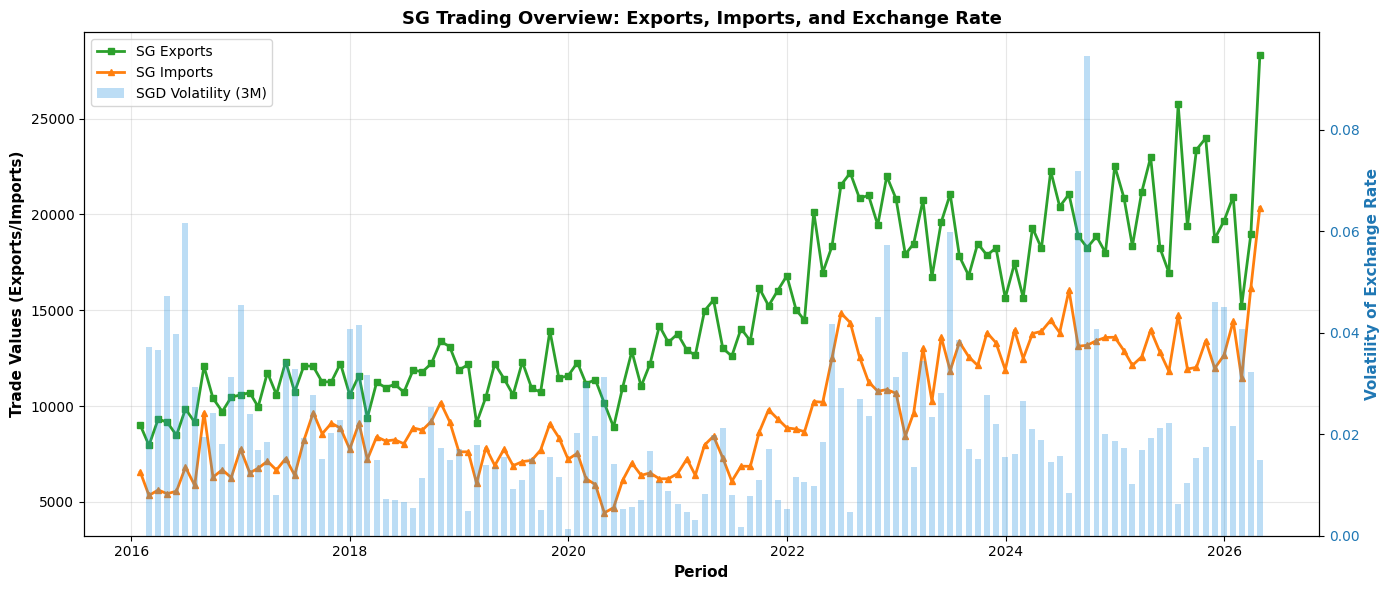

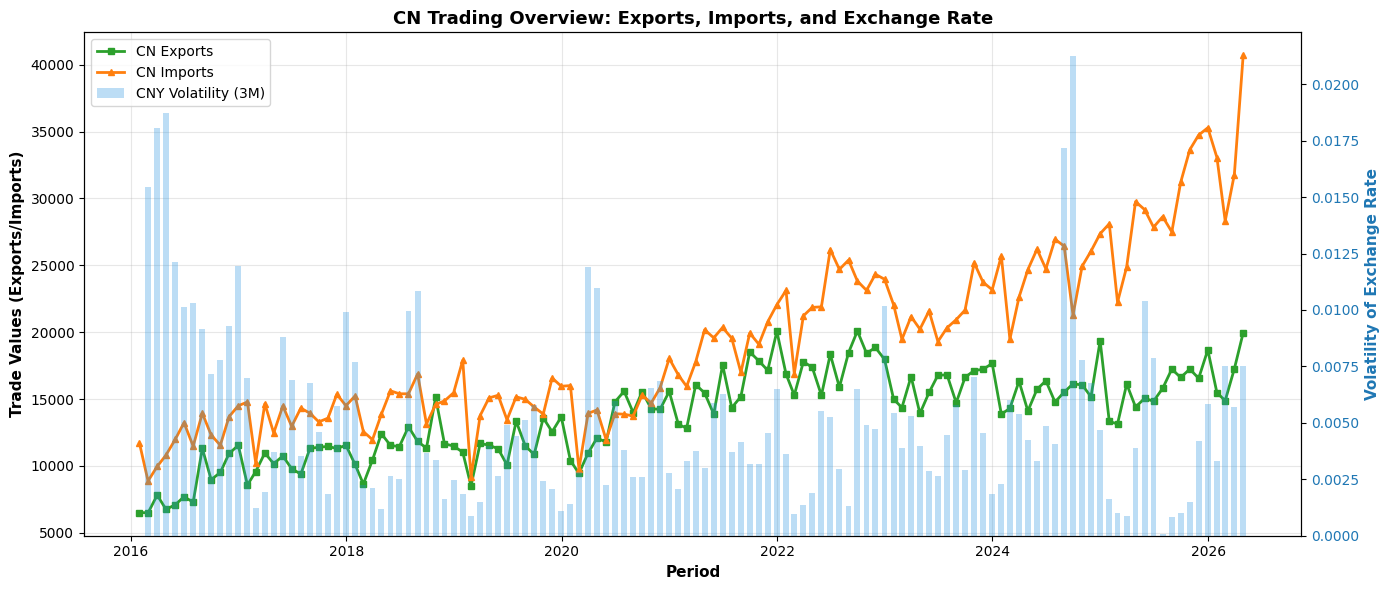


EDA COMPLETE - 3 partner-specific time series graphs generated


In [19]:
print("\n9. TIME SERIES TRENDS ANALYSIS BY COUNTRY")
print("-"*80)

import matplotlib.patches as mpatches

# Create separate plots for each trading partner
for partner in ['US', 'SG', 'CN']:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Determine exchange rate column for this partner
    if partner == 'US':
        rate_col = next((r for r in rate_cols if 'usd' in r.lower()), None)
    elif partner == 'SG':
        rate_col = next((r for r in rate_cols if 'sgd' in r.lower()), None)
    else:  # CN
        rate_col = next((r for r in rate_cols if 'cny' in r.lower() or 'rmb' in r.lower()), None)
    
    # Find export, import, and balance columns for this partner
    exp_col = next((c for c in trade_value_cols if re.search(fr'{partner}.*export|export.*{partner}', c, flags=re.I)), None)
    imp_col = next((c for c in trade_value_cols if re.search(fr'{partner}.*import|import.*{partner}', c, flags=re.I)), None)
    balance_col = f"{partner}_trade_balance" if f"{partner}_trade_balance" in feature_df.columns else None
    
    # Plot with dual y-axes if data exists
    if rate_col and (exp_col or imp_col):
        ax1 = ax
        ax2 = ax1.twinx()
        
        # Left axis: Trade flows (Exports and Imports)
        if exp_col and exp_col in feature_df.columns:
            line1 = ax1.plot(feature_df.index, feature_df[exp_col], marker='s', label=f'{partner} Exports', 
                            linewidth=2, markersize=5, color='#2ca02c')
        if imp_col and imp_col in feature_df.columns:
            line2 = ax1.plot(feature_df.index, feature_df[imp_col], marker='^', label=f'{partner} Imports', 
                            linewidth=2, markersize=5, color='#ff7f0e')
        
        # Right axis: Exchange rate volatility (bar chart)
        if rate_col and rate_col in feature_df.columns:
            vol_col = f"{rate_col}_vol_3m"
            if vol_col in feature_df.columns:
                bars = ax2.bar(feature_df.index, feature_df[vol_col],
                               color="#2191e1", alpha=0.3, width=20,
                               label=f'{rate_col} Volatility (3M)')
        
        ax1.set_xlabel('Period', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Trade Values (Exports/Imports)', fontsize=11, fontweight='bold', color='black')
        ax2.set_ylabel('Volatility of Exchange Rate', fontsize=11, fontweight='bold', color='#1f77b4')
        ax1.set_title(f'{partner} Trading Overview: Exports, Imports, and Exchange Rate', 
                     fontsize=13, fontweight='bold')
        
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='y', labelcolor='black')
        ax2.tick_params(axis='y', labelcolor='#1f77b4')
        
        # Combine legends from both axes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()

        # Merge them cleanly
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("EDA COMPLETE - 3 partner-specific time series graphs generated")
print("="*80)

## 10. Data Splitting

In [20]:
# 13. Data Splitting: Time-based 80/20 split
# We perform a chronological split (first 80% train, last 20% test)
print("\nDATA SPLIT (80/20) - Time-based chronologic split")

# Ensure features are sorted by Period index
if not feature_df.index.is_monotonic_increasing:
    feature_df = feature_df.sort_index()

N = len(feature_df)
if N == 0:
    print('feature_df is empty - nothing to split')
else:
    split_idx = int(N * 0.8)
    train_df = feature_df.iloc[:split_idx].copy()
    test_df = feature_df.iloc[split_idx:].copy()

    # Summary
    print(f'Total rows: {N}, Train: {train_df.shape[0]}, Test: {test_df.shape[0]}')
    print(f'Train period: {train_df.index.min()} to {train_df.index.max()}')
    print(f'Test period: {test_df.index.min()} to {test_df.index.max()}')



DATA SPLIT (80/20) - Time-based chronologic split
Total rows: 124, Train: 99, Test: 25
Train period: 2016-01-31 00:00:00 to 2024-03-31 00:00:00
Test period: 2024-04-30 00:00:00 to 2026-04-30 00:00:00


## 11. Deep Learning Forecasting

In [21]:
import warnings
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import tensorflow
import random

np.random.seed(42)
tensorflow.random.set_seed(42)
random.seed(42)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

try:
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Dropout, GRU, LSTM, Input
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError as e:
    raise ImportError("TensorFlow is required for MLP/GRU/LSTM. Install it with: pip install tensorflow") from e

print('\n' + '='*80)
print('DEEP LEARNING FORECASTING: MLP, GRU, LSTM')
print('='*80)


DEEP LEARNING FORECASTING: MLP, GRU, LSTM


### 11.1 Define six target variables

In [22]:
partner_names = ['US', 'SG', 'CN']
target_cols = []
for partner in partner_names:
    for kind in ['export', 'import']:
        col = next((c for c in trade_value_cols if re.search(rf'{partner}.*{kind}|{kind}.*{partner}', c, flags=re.I)), None)
        if col:
            target_cols.append(col)

target_cols = list(dict.fromkeys(target_cols))
print('Target columns detected:', target_cols)

if len(target_cols) != 6:
    print(f'WARNING: expected 6 targets but found {len(target_cols)}. Available trade columns: {trade_value_cols}')

# Feature columns for modelling
feature_columns = [
    c for c in feature_df.columns
    if c not in target_cols and pd.api.types.is_numeric_dtype(feature_df[c]) and feature_df[c].notna().any()
]

# Fill engineered NaNs introduced by lag / change / volatility features before training.
train_df = train_df[feature_columns + target_cols].copy().fillna(0)
test_df = test_df[feature_columns + target_cols].copy().fillna(0)

print(f'Using {len(feature_columns)} numeric feature columns.')

Target columns detected: ['US Export', 'US Import', 'SG Export', 'SG Import', 'CN Export', 'CN Import']
Using 33 numeric feature columns.


### 11.2 Model Builder

In [23]:
lookback = 6

def create_sequences(df, feature_list, target_name, window_size):
    X, y = [], []
    for i in range(window_size, len(df)):
        X.append(df.iloc[i-window_size:i][feature_list].values)
        y.append(df.iloc[i][target_name])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

def build_mlp(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model


def build_gru(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        GRU(32),
        Dense(16, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model


def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dense(16, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
    return {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }


### 11.3 Train models per target and model type

In [24]:
model_builders = {
    'MLP': build_mlp,
    'GRU': build_gru,
    'LSTM': build_lstm
}

all_results = []
trained_models = {}

for target_col in target_cols:
    print(f'\n=== TARGET: {target_col} ===')

    X_train_seq, y_train = create_sequences(train_df, feature_columns, target_col, lookback)
    X_test_seq, y_test = create_sequences(test_df, feature_columns, target_col, lookback)

    if len(X_train_seq) == 0 or len(X_test_seq) == 0:
        print(f'Not enough data for {target_col}. Skipping.')
        continue

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
    X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

    X_train_scaled = feature_scaler.fit_transform(X_train_flat)
    X_test_scaled = feature_scaler.transform(X_test_flat)

    y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).ravel()

    for model_name, builder in model_builders.items():
        if model_name == 'MLP':
            input_shape = (X_train_scaled.shape[1],)
            model = builder(input_shape)
            X_train_model = X_train_scaled
            X_test_model = X_test_scaled
        else:
            input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
            model = builder(input_shape)
            X_train_model = X_train_scaled.reshape(X_train_seq.shape[0], X_train_seq.shape[1], X_train_seq.shape[2])
            X_test_model = X_test_scaled.reshape(X_test_seq.shape[0], X_test_seq.shape[1], X_test_seq.shape[2])

        early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        history = model.fit(
            X_train_model,
            y_train_scaled,
            validation_split=0.1,
            epochs=80,
            batch_size=8,
            callbacks=[early_stop],
            verbose=0
        )

        y_pred_scaled = model.predict(X_test_model, verbose=0).ravel()
        y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        y_true = target_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

        metrics = compute_metrics(y_true, y_pred)
        print(f'{model_name}: RMSE={metrics["RMSE"]:.4f}, MAE={metrics["MAE"]:.4f}, MAPE={metrics["MAPE"]:.2f}%')

        row = {
            'Target': target_col,
            'Model': model_name,
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE': metrics['MAPE']
        }
        all_results.append(row)
        trained_models[(target_col, model_name)] = model



=== TARGET: US Export ===
MLP: RMSE=6059.5531, MAE=4915.2175, MAPE=21.76%
GRU: RMSE=9196.1941, MAE=8314.9554, MAPE=38.31%
LSTM: RMSE=8121.1513, MAE=7186.8753, MAPE=32.81%

=== TARGET: US Import ===
MLP: RMSE=3440.3709, MAE=2530.6660, MAPE=21.21%
GRU: RMSE=3683.2745, MAE=2788.0462, MAPE=23.24%
LSTM: RMSE=3745.6163, MAE=2851.2256, MAPE=23.85%

=== TARGET: SG Export ===
MLP: RMSE=4224.6311, MAE=3266.7613, MAPE=14.86%
GRU: RMSE=3832.2565, MAE=2809.7707, MAPE=12.53%
LSTM: RMSE=5061.1640, MAE=3897.6739, MAPE=17.19%

=== TARGET: SG Import ===
MLP: RMSE=2316.8106, MAE=1810.6783, MAPE=13.54%
GRU: RMSE=3123.0779, MAE=2144.2317, MAPE=14.23%
LSTM: RMSE=3113.3646, MAE=2319.2526, MAPE=15.74%

=== TARGET: CN Export ===
MLP: RMSE=2080.8492, MAE=1732.7786, MAPE=10.50%
GRU: RMSE=1982.5361, MAE=1569.8765, MAPE=9.89%
LSTM: RMSE=2326.2725, MAE=1913.3515, MAPE=12.38%

=== TARGET: CN Import ===
MLP: RMSE=4622.6392, MAE=4033.6106, MAPE=13.36%
GRU: RMSE=9681.9439, MAE=8872.3260, MAPE=28.64%
LSTM: RMSE=8487.25

### 11.4 Summary table

In [25]:

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['Target', 'Model']).reset_index(drop=True)

print('\n' + '='*80)
print('MODEL PERFORMANCE SUMMARY')
print('='*80)
print(results_df.to_string(index=False))

best_model_by_target = (
    results_df.sort_values(['Target', 'RMSE'], ascending=[True, True])
    .groupby('Target', as_index=False)
    .first()
    .sort_values('Target')
)

print('\n' + '='*80)
print('BEST MODEL FOR EACH TARGET (lowest RMSE)')
print('='*80)
print(best_model_by_target[['Target', 'Model', 'RMSE', 'MAE', 'MAPE']].to_string(index=False))

# results_df.to_csv(r'c:\UM\Project\deep_learning_model_results.csv', index=False)
# best_model_by_target.to_csv(r'c:\UM\Project\deep_learning_best_model_by_target.csv', index=False)
# print('\nSaved full metrics to: c:\\UM\\Project\\deep_learning_model_results.csv')
# print('Saved best-model summary to: c:\\UM\\Project\\deep_learning_best_model_by_target.csv')


MODEL PERFORMANCE SUMMARY
   Target Model        RMSE         MAE      MAPE
CN Export   GRU 1982.536139 1569.876542  9.892631
CN Export  LSTM 2326.272475 1913.351460 12.379713
CN Export   MLP 2080.849225 1732.778577 10.502096
CN Import   GRU 9681.943866 8872.325966 28.641195
CN Import  LSTM 8487.249957 7261.939042 22.888645
CN Import   MLP 4622.639200 4033.610609 13.358565
SG Export   GRU 3832.256522 2809.770713 12.531314
SG Export  LSTM 5061.164039 3897.673880 17.186767
SG Export   MLP 4224.631098 3266.761256 14.863577
SG Import   GRU 3123.077924 2144.231702 14.234530
SG Import  LSTM 3113.364564 2319.252621 15.741365
SG Import   MLP 2316.810559 1810.678300 13.539936
US Export   GRU 9196.194111 8314.955438 38.312549
US Export  LSTM 8121.151327 7186.875308 32.813101
US Export   MLP 6059.553099 4915.217516 21.764208
US Import   GRU 3683.274534 2788.046155 23.240085
US Import  LSTM 3745.616290 2851.225560 23.854576
US Import   MLP 3440.370880 2530.666016 21.208304

BEST MODEL FOR EACH TA

### 11.5 Visualization

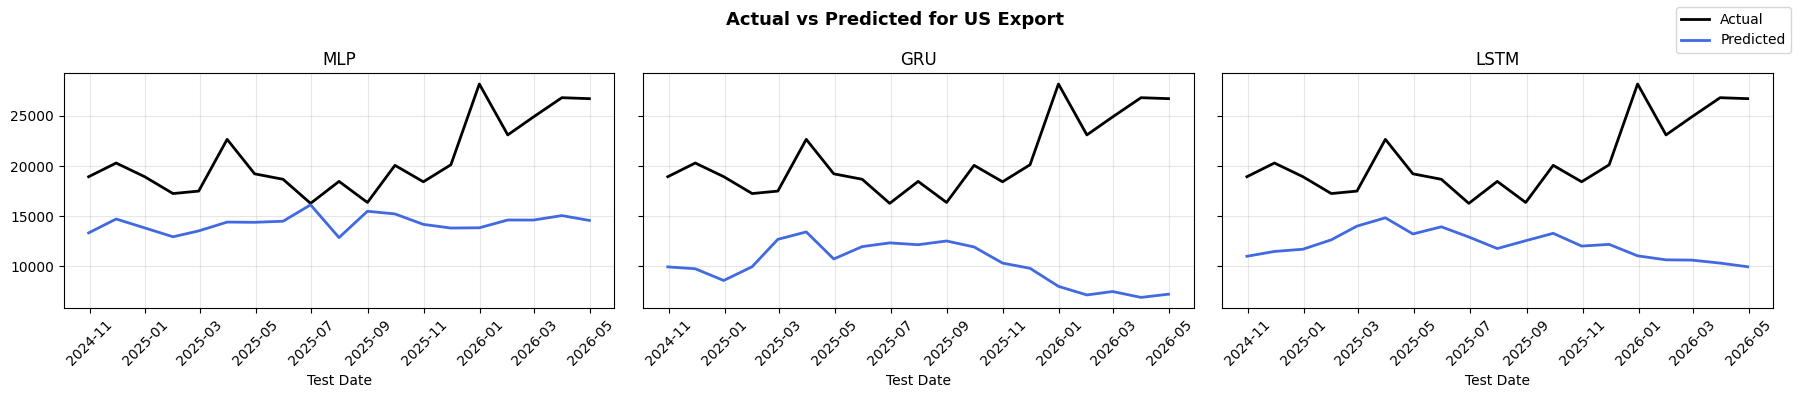

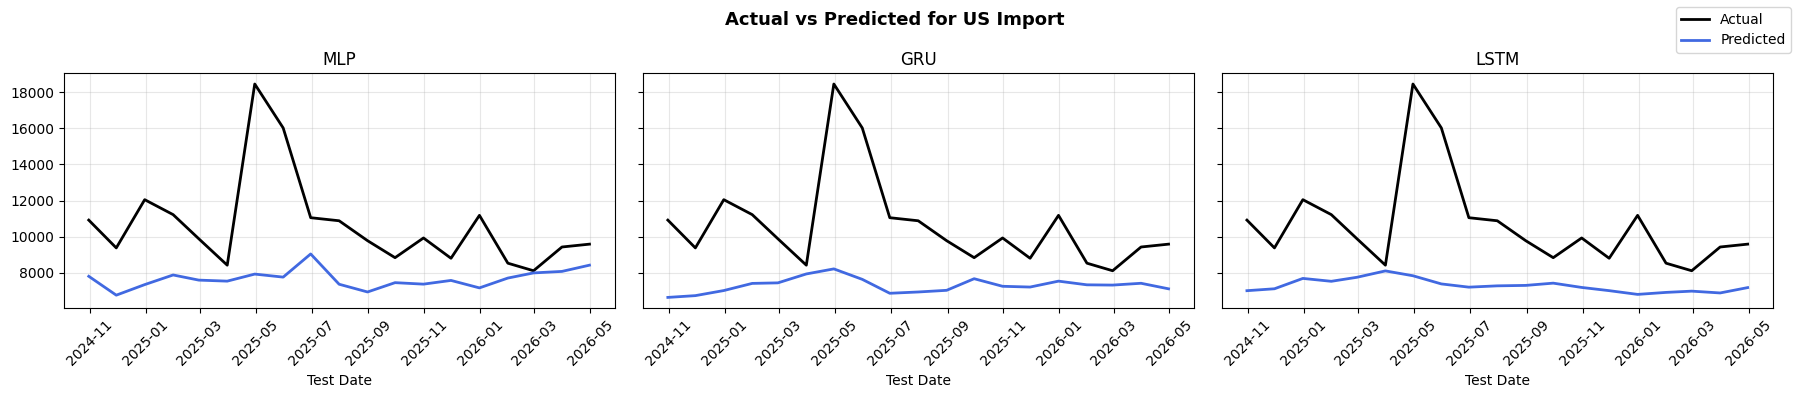

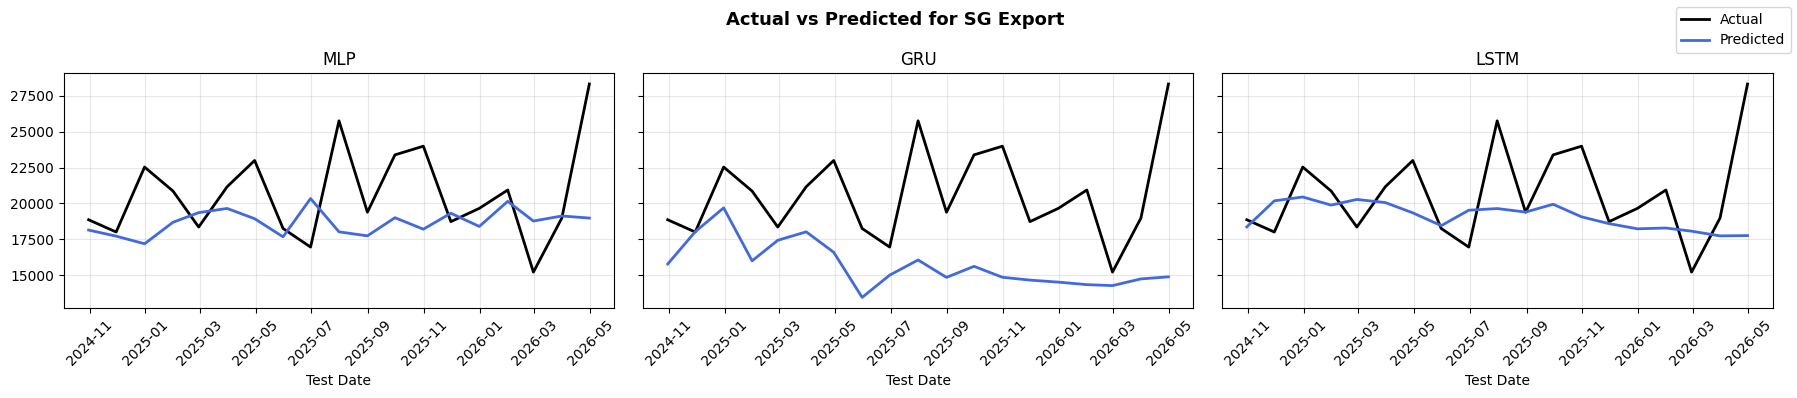

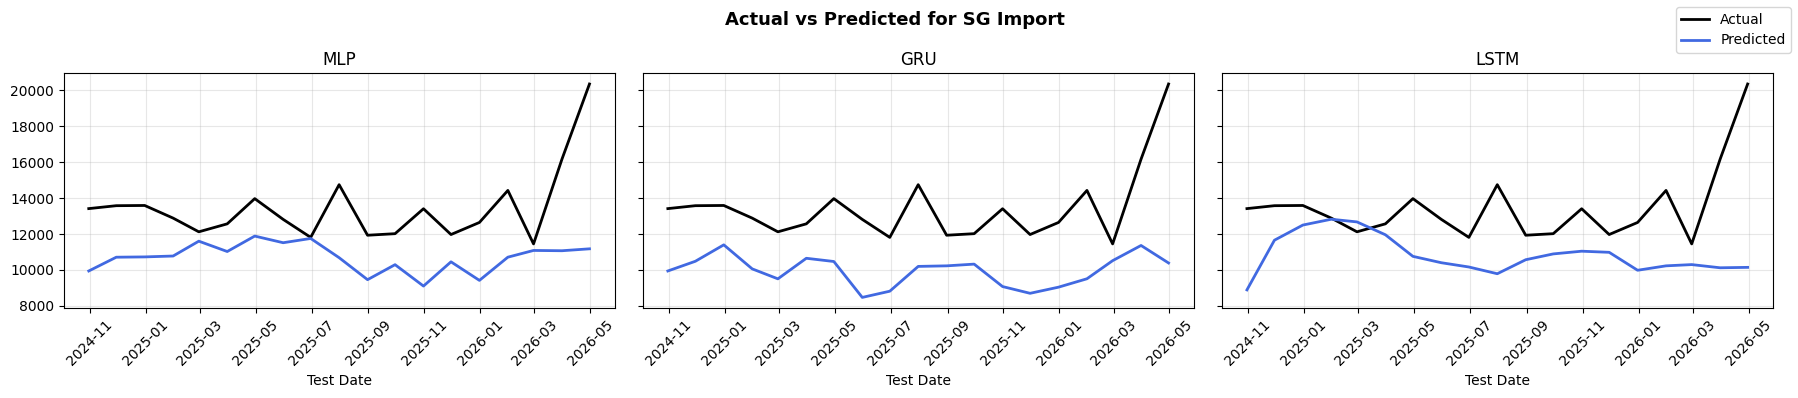

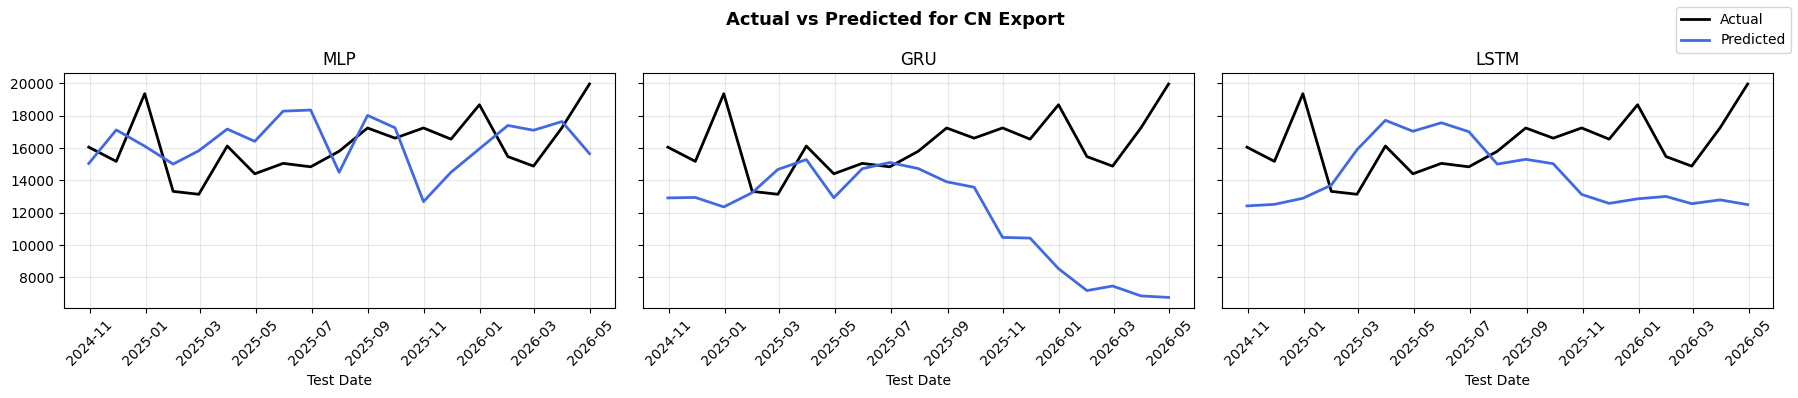

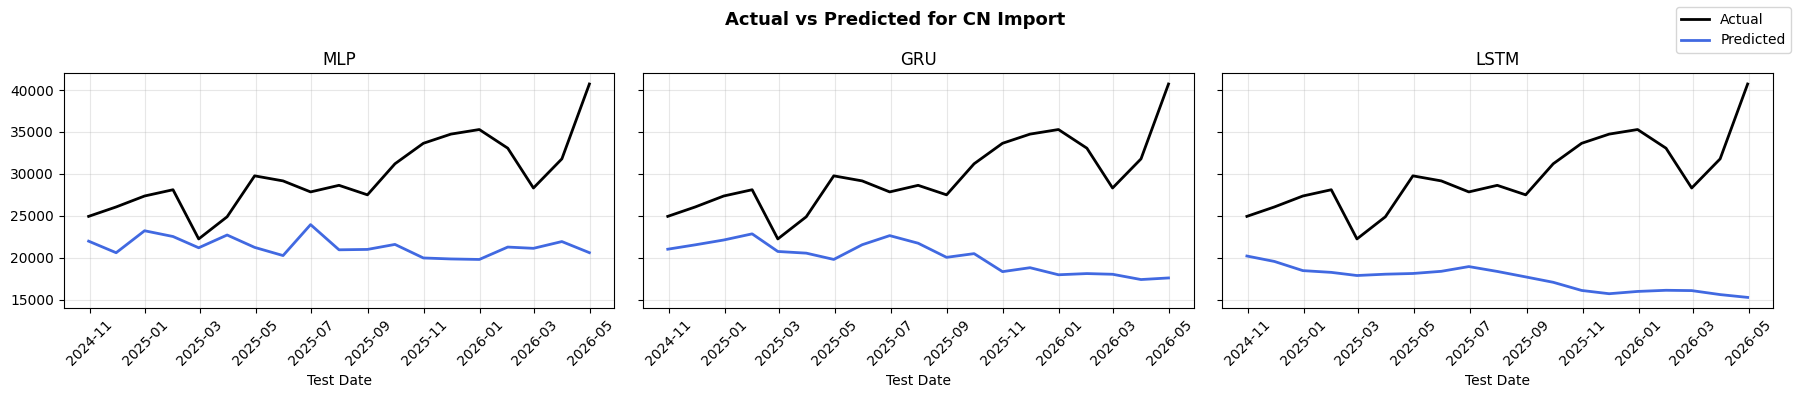

In [26]:

for target_col in target_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    fig.suptitle(f'Actual vs Predicted for {target_col}', fontsize=13, fontweight='bold')

    for ax, model_name in zip(axes, ['MLP', 'GRU', 'LSTM']):
        X_train_seq, y_train = create_sequences(train_df, feature_columns, target_col, lookback)
        X_test_seq, y_test = create_sequences(test_df, feature_columns, target_col, lookback)

        feature_scaler = StandardScaler()
        target_scaler = StandardScaler()

        X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
        X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

        X_train_scaled = feature_scaler.fit_transform(X_train_flat)
        X_test_scaled = feature_scaler.transform(X_test_flat)

        y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
        y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).ravel()

        if model_name == 'MLP':
            model = build_mlp((X_train_scaled.shape[1],))
            X_train_model = X_train_scaled
            X_test_model = X_test_scaled
        else:
            model = build_gru((X_train_seq.shape[1], X_train_seq.shape[2])) if model_name == 'GRU' else build_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))
            X_train_model = X_train_scaled.reshape(X_train_seq.shape[0], X_train_seq.shape[1], X_train_seq.shape[2])
            X_test_model = X_test_scaled.reshape(X_test_seq.shape[0], X_test_seq.shape[1], X_test_seq.shape[2])

        model.fit(X_train_model, y_train_scaled, epochs=80, batch_size=8, verbose=0)
        y_pred_scaled = model.predict(X_test_model, verbose=0).ravel()
        y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        y_true = target_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

        test_dates = test_df.index[lookback:lookback + len(y_true)]
        ax.plot(test_dates, y_true, label='Actual', linewidth=2, color='black')
        ax.plot(test_dates, y_pred, label='Predicted', linewidth=2, color='royalblue')
        ax.set_title(model_name)
        ax.set_xlabel('Test Date')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout()
    plt.show()

### 11.6 Best Model

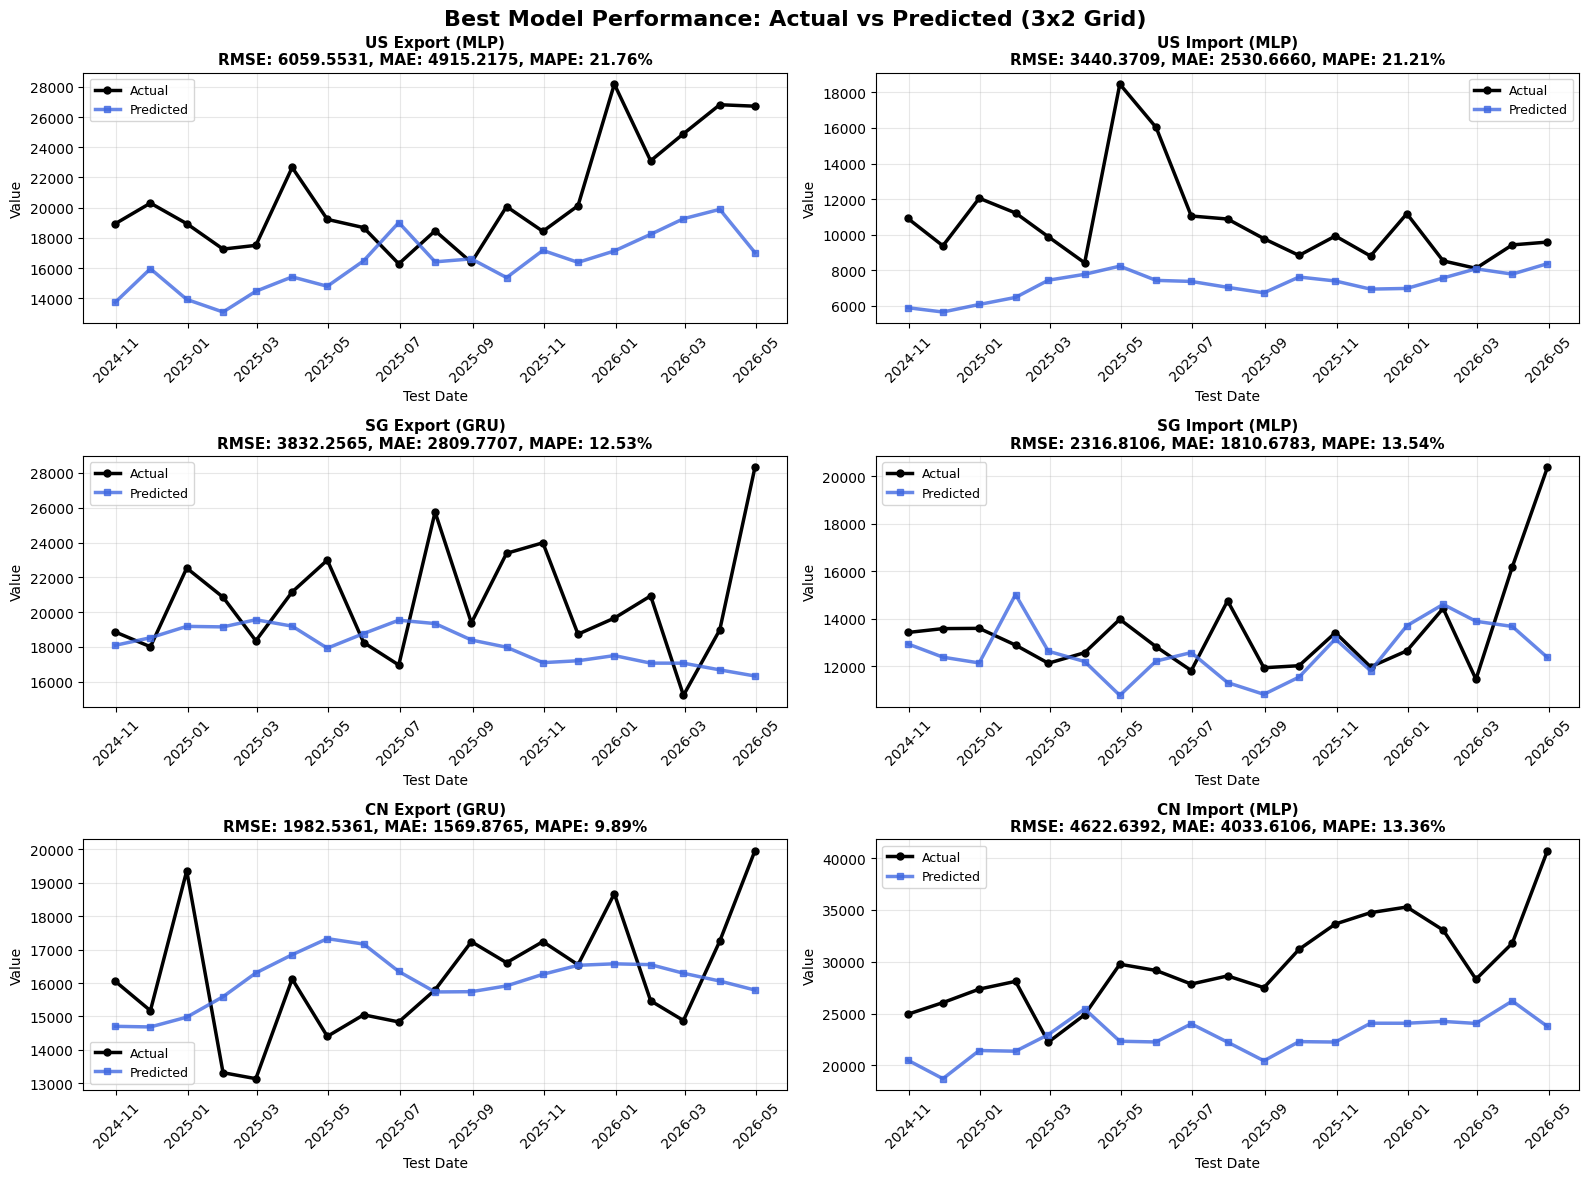


BEST MODEL VISUALIZATION COMPLETE (3x2 Grid)
Each subplot shows the best performing model for that target.
Forecasting workflow completed. The six target variables are modelled with MLP, GRU and LSTM and evaluated using RMSE, MAE and MAPE.


In [27]:

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle('Best Model Performance: Actual vs Predicted (3x2 Grid)', fontsize=16, fontweight='bold')

for idx, target_col in enumerate(target_cols):
    ax = axes[idx]
    
    # Get best model for this target
    best_row = best_model_by_target[best_model_by_target['Target'] == target_col]
    if best_row.empty:
        print(f'No best model found for {target_col}')
        continue
    
    best_model_name = best_row['Model'].values[0]
    best_rmse = best_row['RMSE'].values[0]
    best_mae = best_row['MAE'].values[0]
    best_mape = best_row['MAPE'].values[0]
    
    # Generate sequences
    X_train_seq, y_train = create_sequences(train_df, feature_columns, target_col, lookback)
    X_test_seq, y_test = create_sequences(test_df, feature_columns, target_col, lookback)
    
    if len(X_train_seq) == 0 or len(X_test_seq) == 0:
        print(f'Insufficient data for {target_col}')
        continue
    
    # Scale data
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()
    
    X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
    X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)
    
    X_train_scaled = feature_scaler.fit_transform(X_train_flat)
    X_test_scaled = feature_scaler.transform(X_test_flat)
    
    y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).ravel()
    
    # Build and train best model
    if best_model_name == 'MLP':
        model = build_mlp((X_train_scaled.shape[1],))
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled
    elif best_model_name == 'GRU':
        model = build_gru((X_train_seq.shape[1], X_train_seq.shape[2]))
        X_train_model = X_train_scaled.reshape(X_train_seq.shape[0], X_train_seq.shape[1], X_train_seq.shape[2])
        X_test_model = X_test_scaled.reshape(X_test_seq.shape[0], X_test_seq.shape[1], X_test_seq.shape[2])
    else:  # LSTM
        model = build_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))
        X_train_model = X_train_scaled.reshape(X_train_seq.shape[0], X_train_seq.shape[1], X_train_seq.shape[2])
        X_test_model = X_test_scaled.reshape(X_test_seq.shape[0], X_test_seq.shape[1], X_test_seq.shape[2])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    model.fit(X_train_model, y_train_scaled, validation_split=0.1, epochs=80, batch_size=8, 
              callbacks=[early_stop], verbose=0)
    
    # Predictions
    y_pred_scaled = model.predict(X_test_model, verbose=0).ravel()
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = target_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()
    
    test_dates = test_df.index[lookback:lookback + len(y_true)]
    
    # Plot
    ax.plot(test_dates, y_true, label='Actual', linewidth=2.5, color='black', marker='o', markersize=5)
    ax.plot(test_dates, y_pred, label='Predicted', linewidth=2.5, color='royalblue', marker='s', markersize=4, alpha=0.8)
    ax.set_title(f'{target_col} ({best_model_name})\nRMSE: {best_rmse:.4f}, MAE: {best_mae:.4f}, MAPE: {best_mape:.2f}%', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Date', fontsize=10)
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('BEST MODEL VISUALIZATION COMPLETE (3x2 Grid)')
print('='*80)
print('Each subplot shows the best performing model for that target.')
print('Forecasting workflow completed. The six target variables are modelled with MLP, GRU and LSTM and evaluated using RMSE, MAE and MAPE.')
